In [26]:
import dask
import glob
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from pyproj import Transformer
import matplotlib.colors as mcolors
from shapely.geometry import Polygon, Point
import cartopy.feature as cfeature
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

In [82]:
def get_hudson_masks(ds):
    """
    Create masks for West and South Hudson Bay based on x/y or lat/lon bounds.

    Returns:
        mask_west, mask_south : xarray.DataArray (boolean)
    """

    # Define bounds (lon/lat)
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}

    if 'lat' in ds.coords and 'lon' in ds.coords:
        print("Using lat/lon coordinates for masking")

        mask_west = ((ds.lon >= west_bounds['lon_min']) & (ds.lon <= west_bounds['lon_max']) &
                     (ds.lat >= west_bounds['lat_min']) & (ds.lat <= west_bounds['lat_max']))

        mask_south = ((ds.lon >= south_bounds['lon_min']) & (ds.lon <= south_bounds['lon_max']) &
                      (ds.lat >= south_bounds['lat_min']) & (ds.lat <= south_bounds['lat_max']))

    elif 'x' in ds.coords and 'y' in ds.coords:
        print("Using x/y coordinates for masking")

        # Set up transformer
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)

        # Define West polygon in lon/lat
        west_poly_lonlat = [
            (west_bounds['lon_min'], west_bounds['lat_min']),
            (west_bounds['lon_max'], west_bounds['lat_min']),
            (west_bounds['lon_max'], west_bounds['lat_max']),
            (west_bounds['lon_min'], west_bounds['lat_max']),
            (west_bounds['lon_min'], west_bounds['lat_min'])
        ]

        # Define South polygon in lon/lat
        south_poly_lonlat = [
            (south_bounds['lon_min'], south_bounds['lat_min']),
            (south_bounds['lon_max'], south_bounds['lat_min']),
            (south_bounds['lon_max'], south_bounds['lat_max']),
            (south_bounds['lon_min'], south_bounds['lat_max']),
            (south_bounds['lon_min'], south_bounds['lat_min'])
        ]

        # Transform both polygons to projected x/y
        west_poly_proj = [transformer.transform(lon, lat) for lon, lat in west_poly_lonlat]
        south_poly_proj = [transformer.transform(lon, lat) for lon, lat in south_poly_lonlat]

        # Create shapely polygons
        west_polygon = Polygon(west_poly_proj)
        south_polygon = Polygon(south_poly_proj)

        # Create 2D meshgrid of x and y coordinates from dataset
        xx, yy = np.meshgrid(ds.x.values, ds.y.values)

        # Flatten meshgrid for efficient point-in-polygon testing
        points = np.vstack((xx.ravel(), yy.ravel())).T

        # Create masks by checking if points fall inside polygons
        mask_west_flat = np.array([west_polygon.contains(Point(x, y)) for x, y in points])
        mask_south_flat = np.array([south_polygon.contains(Point(x, y)) for x, y in points])

        # Reshape masks back to 2D (y, x)
        mask_west = xr.DataArray(mask_west_flat.reshape(xx.shape), dims=('y', 'x'), coords={'y': ds.y, 'x': ds.x})
        mask_south = xr.DataArray(mask_south_flat.reshape(xx.shape), dims=('y', 'x'), coords={'y': ds.y, 'x': ds.x})

    else:
        raise ValueError("Dataset does not have expected coordinate system (lat/lon or x/y)")

    return mask_west, mask_south


def plot_hudson_bay(ds_sel, west_mask, south_mask):
    # Define projections
    crs = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45
    )

    crs_nsidc = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45,
        true_scale_latitude=70,
        false_easting=0,
        false_northing=0
    )

    # Define levels (boundaries for the colors)
    levels = np.linspace(0, 100, 11)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=plt.cm.Blues_r.N, clip=True)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})

    # Ocean
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # Sea ice concentration
    im = ax.pcolormesh(
        ds.x.values,
        ds.y.values,
        ds_sel.where(west_mask).values,
        cmap='Blues_r',
        norm=norm,
        transform=crs_nsidc,
        zorder=1
    )

    im = ax.pcolormesh(
        ds.x.values,
        ds.y.values,
        ds_sel.where(south_mask).values,
        cmap='Blues_r',
        norm=norm,
        transform=crs_nsidc,
        zorder=1
    )

    # Land
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # Coastlines
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_extent = [-87, -80, 49, 67]
    ax.set_extent(hudson_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, color='white')

    # West and South Hudson Bay boxes
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}

    draw_box(ax, west_bounds, edgecolor='red', linewidth=2)
    draw_box(ax, south_bounds, edgecolor='red', linewidth=2)

    ax.text(-90, 60, "West", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')
    ax.text(-85, 54, "South", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')

    # Colorbar with percentage formatting
    cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=levels, pad=0.05, shrink=0.7)
    cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

    # Title in same style
    date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
    ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

    plt.tight_layout()
    plt.show()


def plot_metrics_map(metric_west, metric_south, levels, cmap, label):
    # Define projections
    crs = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45
    )

    crs_nsidc = ccrs.Stereographic(
        central_latitude=90,
        central_longitude=-45,
        true_scale_latitude=70,
        false_easting=0,
        false_northing=0
    )

    # Create a normalization object that maps values to colormap bins
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256, clip=True)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})

    # Ocean
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')

    # Sea ice concentration
    im = ax.pcolormesh(
        metric_west.x.values,
        metric_west.y.values,
        metric_west.values,
        cmap=cmap,
        norm=norm,
        transform=crs_nsidc,
        zorder=1
    )

    im = ax.pcolormesh(
        metric_south.x.values,
        metric_south.y.values,
        metric_south,
        cmap=cmap,
        norm=norm,
        transform=crs_nsidc,
        zorder=1
    )

    # Land
    ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=2, facecolor='gray', edgecolor='black', linewidth=0.5)

    # Coastlines
    ax.coastlines(resolution='50m', zorder=3)

    # Approximate extent around Hudson Bay in degrees
    hudson_extent = [-87, -80, 49, 67]
    ax.set_extent(hudson_extent, crs=ccrs.PlateCarree())

    # Gridlines
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, color='white')

    # West and South Hudson Bay boxes
    west_bounds = {'lon_min': -95, 'lon_max': -88, 'lat_min': 56, 'lat_max': 63}
    south_bounds = {'lon_min': -88, 'lon_max': -75, 'lat_min': 51, 'lat_max': 60}

    draw_box(ax, west_bounds, edgecolor='red', linewidth=2)
    draw_box(ax, south_bounds, edgecolor='red', linewidth=2)

    ax.text(-90, 60, "West", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')
    ax.text(-85, 54, "South", transform=ccrs.PlateCarree(), fontsize=12, color='red', ha='center', va='center', fontweight='bold')

    # Define useful ticks (approx DOY for each month)
    tick_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274]

    # Colorbar
    cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=tick_days, pad=0.05, shrink=0.7)
    cbar.set_ticklabels(pd.to_datetime(tick_days, format='%j').strftime('%b %d'))
    cbar.set_label(label, fontsize=12)

    plt.tight_layout()
    plt.show()


def draw_box(ax, bounds, edgecolor='red', linewidth=2):
    """
    Draw a rectangular box on a Cartopy map.

    Parameters:
    - ax: matplotlib axis with cartopy projection
    - bounds: dict with keys 'lon_min', 'lon_max', 'lat_min', 'lat_max'
    """
    # Corners of the box in lon/lat
    lons = [bounds['lon_min'], bounds['lon_max'], bounds['lon_max'], bounds['lon_min'], bounds['lon_min']]
    lats = [bounds['lat_min'], bounds['lat_min'], bounds['lat_max'], bounds['lat_max'], bounds['lat_min']]

    # Plot the box using PlateCarree projection (geodetic)
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), color=edgecolor, linewidth=linewidth)

In [20]:
# Combined data
vars = ['am2_seaice_conc', 'cdr_seaice_conc', 'ICECON', 'sic']

# Allocate for dataset information
names, ds_all = [], []

for file_path in glob.glob('/glade/work/skygale/pbi-data/combined/*.nc'):
    name = file_path[38:-3]
    names.append(name)
    print(f'Processing {name}...')

    # Open dataset
    ds = xr.open_dataset(file_path, chunks={})

    # Get sea ice
    for varname in vars:
        if varname in ds.data_vars:
            da = ds[varname]
            break

    # Standardize DataArray names
    rename_dict = {}
    if 'ni' in da.dims:
        rename_dict['ni'] = 'x'
    if 'nj' in da.dims:
        rename_dict['nj'] = 'y'
    da = da.rename(rename_dict)

    # Convert any fractions to percentage
    max_val = da.max(skipna=True)
    if max_val <= 1.05:
        print('    Fraction! --> Converting to percentage.')
        da = da * 100

    # Reorder dimensions
    existing_dims = [dim for dim in ['time', 'y', 'x'] if dim in da.dims]
    da = da.transpose(*existing_dims)

    ds_all.append(da)

Processing G10016_PROTO_25km_2025...
    Fraction! --> Converting to percentage.
Processing AMSR2_12.5km_2012_2025...
Processing AMSR2_25km_2012_2025...
Processing NSIDC_0803_25km_2023_2025...
    Fraction! --> Converting to percentage.
Processing G02202_25km_1978_2025...
    Fraction! --> Converting to percentage.


In [83]:
# Example calculations
idx = -1
ds = ds_all[idx].sel(time='2025')
west_mask, south_mask = get_hudson_masks(ds)

# Check if any points are masked in
print(names[idx])
print("Any West Hudson Bay:", west_mask.any().item())
print("Any South Hudson Bay:", south_mask.any().item())

# Get regions for calculations
ds_west = ds.where(west_mask, drop=True)
ds_south = ds.where(south_mask, drop=True)

ds_west

Using x/y coordinates for masking
G02202_25km_1978_2025
Any West Hudson Bay: True
Any South Hudson Bay: True


<xarray.DataArray 'cdr_seaice_conc' (time: 251, y: 34, x: 34)> Size: 2MB
dask.array<where, shape=(251, 34, 34), dtype=float64, chunksize=(1, 34, 34), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 272B -2.888e+06 -2.862e+06 ... -2.088e+06 -2.062e+06
  * y        (y) float64 272B -1.938e+06 -1.962e+06 ... -2.738e+06 -2.762e+06
  * time     (time) datetime64[ns] 2kB 2025-01-01 2025-01-02 ... 2025-09-08

In [84]:
def calc_IFD_Nday(da, sic_threshold, DOY_s, time_dim, Nday, default_ice_free):
    '''
    Calculate the first Ice-Free Day (IFD) for each calendar year, for each pixel.

    Parameters:
        da (xr.DataArray): Sea ice concentration data (percent).
        sic_threshold (float): SIC threshold.
        time_dim (str): Name of time dimension (usually "time").
        Nday (int): Number of consecutive ice-free days required.
        default_ice_free (int): Default DOY to assign for always ice-free pixels.

    Returns:
        xr.DataArray: Ice-Free Day of Year (DOY) for each year, with dims (year, y, x)
    '''
    da = da.sortby(time_dim)

    # Ensure we have 'year' coordinate
    years = da[time_dim].dt.year
    da_grouped = da.groupby(years)

    ifd_list = []

    for year, da_year in da_grouped:
        # Extract DOY of the first day in the year
        DOY_s = pd.to_datetime(da_year[time_dim].values[0]).timetuple().tm_yday

        # Rolling sum of ice-free condition
        ice_free = (da_year < sic_threshold)
        rolling_ice_free = ice_free.rolling({time_dim: Nday}, center=False, min_periods=1).sum()
        full_free = (rolling_ice_free == Nday).astype(float)

        # First occurrence of full-free period
        ifd = full_free.argmax(dim=time_dim)
        ifd = ifd + DOY_s - Nday - 1

        # Handle pixels that were already ice-free
        ifd = ifd.where(ifd > DOY_s, other=default_ice_free)

        # Pixels that never become ice-free (NaN)
        perenial_mask = (da_year.min(dim=time_dim) >= sic_threshold)
        # ifd = ifd.where(~perenial_mask, other=275)
        ifd = ifd.where(~perenial_mask, other=np.nan)

        # Keep valid data only
        ifd = ifd.where(da_year.isel({time_dim: 0}).notnull())

        # Add year as coordinate
        ifd = ifd.expand_dims(dim={'year': [year]})
        ifd_list.append(ifd)

    # Concatenate all years
    ifd_all_years = xr.concat(ifd_list, dim='year')

    return ifd_all_years

In [85]:
west_ifd = calc_IFD_Nday(
    ds_west,
    sic_threshold=30,
    DOY_s=1,
    time_dim='time',
    Nday=3,
    default_ice_free=None
)

south_ifd = calc_IFD_Nday(
    ds_south,
    sic_threshold=30,
    DOY_s=1,
    time_dim='time',
    Nday=3,
    default_ice_free=None
)

south_ifd

<xarray.DataArray 'cdr_seaice_conc' (year: 1, y: 55, x: 53)> Size: 23kB
dask.array<getitem, shape=(1, 55, 53), dtype=float64, chunksize=(1, 14, 14), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 8B 2025
  * x        (x) float64 424B -2.988e+06 -2.962e+06 ... -1.712e+06 -1.688e+06
  * y        (y) float64 440B -2.438e+06 -2.462e+06 ... -3.762e+06 -3.788e+06
    time     datetime64[ns] 8B 2025-01-01

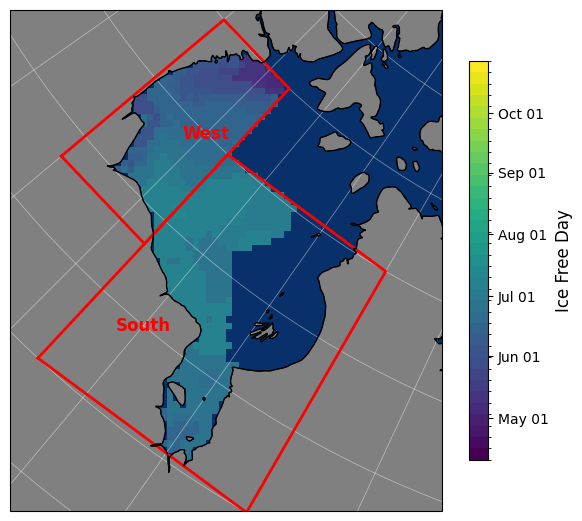

In [88]:
plot_metrics_map(
    west_ifd.sel(year=2025),
    south_ifd.sel(year=2025),
    levels=np.linspace(100, 300, 36),
    cmap='viridis',
    label='Ice Free Day'
)

['Jun 13']
['Jun 30']


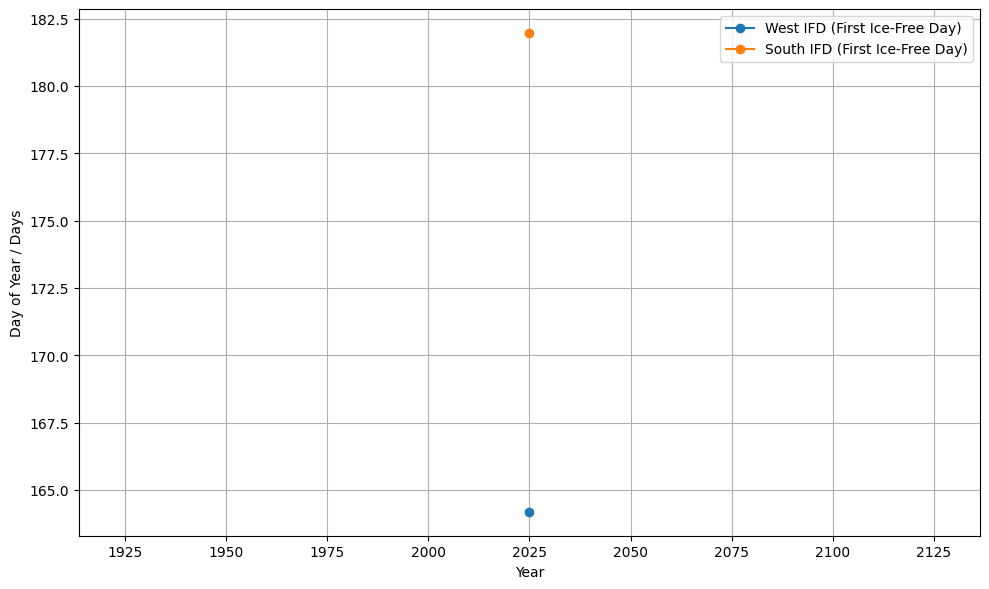

In [89]:
# Spatial average (mean over y and x)
west_ifd_mean = west_ifd.mean(dim=('y', 'x'), skipna=True)
south_ifd_mean = south_ifd.mean(dim=('y', 'x'), skipna=True)

# Your DOY values
doy_values = west_ifd_mean.values

# Convert to datetime (assuming 2024 is a leap year — adjust if needed)
dates = pd.to_datetime(doy_values, origin='2024-01-01', unit='D')

# Display in desired format
formatted = dates.strftime('%b %d')  # e.g., 'Jun 08'

print(formatted.tolist())

# Your DOY values
doy_values = south_ifd_mean.values

# Convert to datetime (assuming 2024 is a leap year — adjust if needed)
dates = pd.to_datetime(doy_values, origin='2024-01-01', unit='D')

# Display in desired format
formatted = dates.strftime('%b %d')  # e.g., 'Jun 08'

print(formatted.tolist())

# Time array
years = west_ifd['year'].values

# Plot
plt.figure(figsize=(10, 6))
plt.plot(years, west_ifd_mean, label='West IFD (First Ice-Free Day)', marker='o')
plt.plot(years, south_ifd_mean, label='South IFD (First Ice-Free Day)', marker='o')
plt.xlabel('Year')
plt.ylabel('Day of Year / Days')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_regional_timeseries(ifd, ibud, numifd, region_name):
    years = ifd['year'].values

    # Spatial average (mean over y and x)
    ifd_mean = ifd.mean(dim=('y', 'x'), skipna=True)
    ibud_mean = ibud.mean(dim=('y', 'x'), skipna=True)
    numifd_mean = numifd.mean(dim=('y', 'x'), skipna=True)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, ifd_mean, label='IFD (First Ice-Free Day)', marker='o')
    plt.plot(years, ibud_mean, label='IBUD (Last Ice Day)', marker='x')
    plt.plot(years, numifd_mean, label='Num IFDs (Total Ice-Free Days)', marker='s')

    plt.title(f'{region_name}: Ice-Free Day Statistics Over Time')
    plt.xlabel('Year')
    plt.ylabel('Day of Year / Days')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
def calc_IBUD_Nday(da, sic_threshold, time_dim, Nday):
    '''
    Calculate the last day where ice is present before becoming ice-free for at least Nday.

    Returns a DataArray with dims (year, y, x) of DOY.
    '''
    da = da.sortby(time_dim)

    years = da[time_dim].dt.year
    da_grouped = da.groupby(years)

    ibud_list = []

    for year, da_year in da_grouped:
        # Sort in reverse to search from end of year
        da_rev = da_year.isel({time_dim: slice(None, None, -1)})

        DOY_s = pd.to_datetime(da_rev[time_dim].values[0]).timetuple().tm_yday

        ice_free = (da_rev < sic_threshold)
        rolling_ice_free = ice_free.rolling({time_dim: Nday}, center=False, min_periods=1).sum()
        full_free = (rolling_ice_free == Nday).astype(float)

        # argmax gives first ice-free N-day from the **end of year**
        ibud_idx = full_free.argmax(dim=time_dim)

        # Convert to DOY: because we're reversed, subtract from end of year
        days_in_year = pd.Timestamp(f"{year}-12-31").timetuple().tm_yday
        ibud_doy = days_in_year - ibud_idx - Nday + 1  # trailing label fix

        # Mask perennial ice (never goes below threshold)
        perenial_mask = (da_year.min(dim=time_dim) >= sic_threshold)
        ibud_doy = ibud_doy.where(~perenial_mask, other=np.nan)

        # Valid data only
        ibud_doy = ibud_doy.where(da_year.isel({time_dim: 0}).notnull())

        # Add year
        ibud_doy = ibud_doy.expand_dims(dim={'year': [year]})
        ibud_list.append(ibud_doy)

    return xr.concat(ibud_list, dim='year')


In [ ]:
def calc_NumIFD(da, sic_threshold, time_dim):
    '''
    Calculate number of ice-free days (SIC < threshold) for each pixel, per year.
    '''
    da = da.sortby(time_dim)

    # Binary mask of ice-free days
    ice_free = (da < sic_threshold)

    # Group by year and count
    num_ifd = ice_free.groupby(da[time_dim].dt.year).sum(dim=time_dim, skipna=True)

    # Name dimension properly
    num_ifd = num_ifd.rename({'year': 'year'})

    return num_ifd


In [94]:
def calc_breakup_freezeup_icefree(
    sic: xr.DataArray,
    extent_thresholds=[10,20,30,40,50,60,70,80,90],
    area_thresholds=[10,20,30,40,50,60,70,80,90],
    require_persistence=True,
    persistence_days=3,
    search_window=(90, 260)
) -> xr.Dataset:
    """
    Calculate breakup, freezeup and ifd dates for a single basin.

    Parameters:
        sic: xr.DataArray
            Sea ice concentration (0-100), dims: (time, y, x). Must be masked to the basin already.
        extent_thresholds: list[int]
            SIC thresholds (%) to define ice-covered grid cells.
        area_thresholds: list[int]
            % of March mean extent to define threshold for break-up/freeze-up.
        require_persistence: bool
            Whether to require `persistence_days` consecutive days below/above threshold.
        persistence_days: int
            Number of days for persistence check.
        search_window: tuple[int]
            Day-of-year window for searching break-up (e.g., (90, 260)).

    Returns:
        xr.Dataset with breakup_day, freezeup_day, and ifd [dims: extent_threshold, area_threshold, year]
    """
    # Convert to Dask if needed
    if not sic.chunks:
        sic = sic.chunk({'time': -1, 'y': 'auto', 'x': 'auto'})

    # Ensure time is sorted
    sic = sic.sortby('time')
    time = sic['time']
    years = np.unique(time.dt.year.values)

    extent_thresholds = np.array(extent_thresholds)
    area_thresholds = np.array(area_thresholds)
    n_ext, n_area, n_years = len(extent_thresholds), len(area_thresholds), len(years)

    # Get March mean extent (per threshold)
    march = sic.sel(time=sic['time'].dt.month == 3)
    march_extent_ref = []
    for e_thr in extent_thresholds:
        is_ice = (march >= e_thr)
        extent = is_ice.sum(dim=['y', 'x'])  # count of icy pixels
        avg_extent = extent.mean(dim='time').compute().item()
        march_extent_ref.append(avg_extent)
    march_extent_ref = np.array(march_extent_ref)

    # Prepare output arrays
    breakup_day = np.full((n_ext, n_area, n_years), np.nan)
    freezeup_day = np.full((n_ext, n_area, n_years), np.nan)

    # Loop over extent and area thresholds
    for e_idx, e_thr in enumerate(extent_thresholds):
        sic_bin = sic >= e_thr  # (time, y, x)
        extent_ts = sic_bin.sum(dim=['y', 'x'])  # (time,)
        extent_ts.load()  # load now for speed

        for a_idx, a_thr in enumerate(area_thresholds):
            extent_thresh = (a_thr / 100.0) * march_extent_ref[e_idx]

            for y_idx, year in enumerate(years):
                # Current year and (optionally) next year
                time_mask = sic['time'].dt.year == year
                extent_y = extent_ts.sel(time=time_mask)
                doy = extent_y['time'].dt.dayofyear

                # Break-up: first time extent < threshold in spring/summer
                breakup_mask = (doy >= search_window[0]) & (doy <= search_window[1])
                cond = extent_y < extent_thresh
                cond = cond.where(breakup_mask, drop=True)

                if require_persistence:
                    roll = cond.rolling(time=persistence_days).sum()
                    valid = roll == persistence_days
                else:
                    valid = cond

                if valid.any().compute():
                    idx = int(np.argmax(valid.values))
                    date = cond['time'].values[idx]
                    breakup_day[e_idx, a_idx, y_idx] = pd.to_datetime(date).timetuple().tm_yday

                # Freeze-up: first time extent ≥ threshold after DOY 250 (look into next year)
                time_window = (sic['time'].dt.year == year) | (sic['time'].dt.year == year + 1)
                extent_f = extent_ts.sel(time=time_window)
                doy_f = extent_f['time'].dt.dayofyear
                freeze_mask = (doy_f >= 250) | (doy_f <= 100)
                cond_f = extent_f >= extent_thresh
                cond_f = cond_f.where(freeze_mask, drop=True)

                if require_persistence:
                    roll_f = cond_f.rolling(time=persistence_days).sum()
                    valid_f = roll_f == persistence_days
                else:
                    valid_f = cond_f

                if valid_f.any().compute():
                    idx_f = int(np.argmax(valid_f.values))
                    date_f = cond_f['time'].values[idx_f]
                    freezeup_day[e_idx, a_idx, y_idx] = pd.to_datetime(date_f).timetuple().tm_yday

    # Create Dataset
    ds = xr.Dataset(
        {
            "breakup_day": (["extent_threshold", "area_threshold", "year"], breakup_day),
            "freezeup_day": (["extent_threshold", "area_threshold", "year"], freezeup_day),
            "ifd": (["extent_threshold", "area_threshold", "year"], freezeup_day - breakup_day)
        },
        coords={
            "extent_threshold": extent_thresholds,
            "area_threshold": area_thresholds,
            "year": years
        }
    )
    return ds

In [96]:
west_metrics = calc_breakup_freezeup_icefree(ds_west)
south_metrics = calc_breakup_freezeup_icefree(ds_south)


In [97]:
west_metrics

<xarray.Dataset> Size: 2kB
Dimensions:           (extent_threshold: 9, area_threshold: 9, year: 1)
Coordinates:
  * extent_threshold  (extent_threshold) int64 72B 10 20 30 40 50 60 70 80 90
  * area_threshold    (area_threshold) int64 72B 10 20 30 40 50 60 70 80 90
  * year              (year) int64 8B 2025
Data variables:
    breakup_day       (extent_threshold, area_threshold, year) float64 648B 1...
    freezeup_day      (extent_threshold, area_threshold, year) float64 648B 3...
    ifd               (extent_threshold, area_threshold, year) float64 648B -...

In [110]:
from datetime import datetime, timedelta, date as dt_date

west_target_date = dt_date(2025, 6, 19)
south_target_date = dt_date(2025, 6, 28)

for extent in west_metrics.extent_threshold:
    for area in west_metrics.area_threshold:

        # West
        doy_west = west_metrics.breakup_day.sel(year=2025, extent_threshold=extent, area_threshold=area).values
        if np.isnan(doy_west):
            continue
        date_west = datetime(2025, 1, 1) + timedelta(days=int(doy_west) - 1)

        # South
        doy_south = south_metrics.breakup_day.sel(year=2025, extent_threshold=extent, area_threshold=area).values
        if np.isnan(doy_south):
            continue
        date_south = datetime(2025, 1, 1) + timedelta(days=int(doy_south) - 1)

        if date_west.date() == west_target_date and date_south.date() == south_target_date:
            print("Match found at extent:", extent.item(), "area:", area.item(), date_west.date(), date_south.date())

Match found at extent: 60 area: 30 2025-06-19 2025-06-28
